# Algebraic syndromes versus Qiskit circuits

This notebook verifies that ideal Qiskit syndrome-extraction circuits reproduce the binary CSS formulas

$$
s_X=H_Xe_Z^T,
\qquad
s_Z=H_Ze_X^T.
$$

The comparison uses two circuits. The X-check circuit starts from $|+\rangle^{\otimes n}$ and detects $Z$ errors; the Z-check circuit starts from $|0\rangle^{\otimes n}$ and detects $X$ errors. This avoids requiring encoded-state preparation while testing the complete matrix-to-circuit translation.

In [2]:
import numpy as np
from qiskit.visualization import plot_histogram

from homoloqode import toric_code
from homoloqode.integrations import simulate_syndrome

## 1. Construct the reference code

We use the periodic square toric code with $L=3$, containing 18 physical qubits and two logical qubits.

In [3]:
code = toric_code(3)

print(f"[[n, k]] = [[{code.n}, {code.k}]]")
print("X checks:", code.hx.shape[0])
print("Z checks:", code.hz.shape[0])

[[n, k]] = [[18, 2]]
X checks: 9
Z checks: 9


## 2. Choose a physical Pauli error

A Pauli error is represented by two binary vectors $(e_X\mid e_Z)$. A position present in both vectors represents a $Y$ error, up to an irrelevant phase.

In [4]:
x_error = np.zeros(code.n, dtype=np.uint8)
z_error = np.zeros(code.n, dtype=np.uint8)

x_error[code.qubit_labels.index("e_h[0,0]")] = 1
z_error[code.qubit_labels.index("e_v[1,1]")] = 1

y_index = code.qubit_labels.index("e_h[2,2]")
x_error[y_index] = 1
z_error[y_index] = 1

for label, x_bit, z_bit in zip(code.qubit_labels, x_error, z_error):
    if x_bit or z_bit:
        pauli = "Y" if x_bit and z_bit else "X" if x_bit else "Z"
        print(f"{pauli} on {label}")

X on e_h[0,0]
Y on e_h[2,2]
Z on e_v[1,1]


## 3. Compute the algebraic syndrome

`CSSCode.syndrome` performs the two matrix-vector products over $\mathbb F_2$.

In [5]:
algebraic = code.syndrome(x_error=x_error, z_error=z_error)

algebraic_x_labels = [
    label
    for label, bit in zip(code.x_check_labels, algebraic.x_checks)
    if bit
]
algebraic_z_labels = [
    label
    for label, bit in zip(code.z_check_labels, algebraic.z_checks)
    if bit
]

print("s_X =", algebraic.x_checks, algebraic_x_labels)
print("s_Z =", algebraic.z_checks, algebraic_z_labels)

s_X = [0 0 0 0 1 0 1 1 1] ['v[1,1]', 'v[0,2]', 'v[1,2]', 'v[2,2]']
s_Z = [1 0 0 0 0 1 1 0 1] ['f[0,0]', 'f[2,1]', 'f[0,2]', 'f[2,2]']


## 4. Extract the same syndrome with Qiskit

The adapter constructs both circuits, executes them with Qiskit's local `BasicSimulator`, and reverses Qiskit's displayed classical-bit order so that the returned vectors follow the row order of $H_X$ and $H_Z$.

In [6]:
qiskit_result = simulate_syndrome(
    code,
    x_error=x_error,
    z_error=z_error,
    shots=32,
    seed=2026,
)

print("Qiskit X-check counts:", qiskit_result.x_check_counts)
print("Qiskit Z-check counts:", qiskit_result.z_check_counts)
print("Qiskit s_X:", qiskit_result.syndrome.x_checks)
print("Qiskit s_Z:", qiskit_result.syndrome.z_checks)

Qiskit X-check counts: {'111010000': 32}
Qiskit Z-check counts: {'101100001': 32}
Qiskit s_X: [0 0 0 0 1 0 1 1 1]
Qiskit s_Z: [1 0 0 0 0 1 1 0 1]


In [7]:
x_agrees = np.array_equal(
    algebraic.x_checks,
    qiskit_result.syndrome.x_checks,
)
z_agrees = np.array_equal(
    algebraic.z_checks,
    qiskit_result.syndrome.z_checks,
)

print("X-check syndromes agree:", x_agrees)
print("Z-check syndromes agree:", z_agrees)
assert x_agrees and z_agrees

X-check syndromes agree: True
Z-check syndromes agree: True


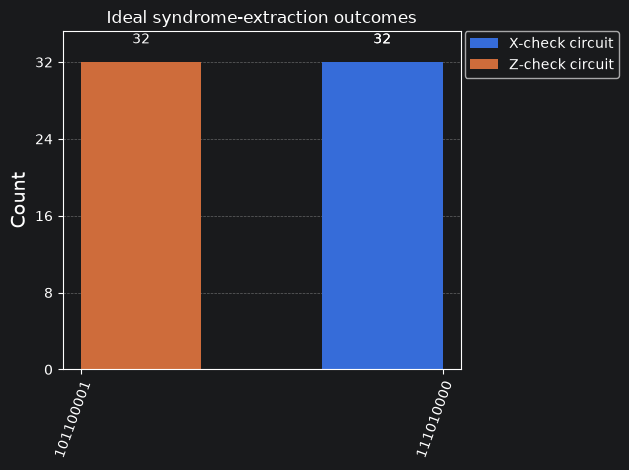

In [8]:
plot_histogram(
    [qiskit_result.x_check_counts, qiskit_result.z_check_counts],
    legend=["X-check circuit", "Z-check circuit"],
    title="Ideal syndrome-extraction outcomes",
)

## 5. Inspect the generated circuits

Each circuit contains the 18 data qubits and one reused ancilla. Reuse keeps the ideal simulation small, but the resulting circuit is not claimed to be a fault-tolerant schedule.

In [9]:
for name, circuit in (
    ("X checks", qiskit_result.circuits.x_checks),
    ("Z checks", qiskit_result.circuits.z_checks),
):
    print(name)
    print("  qubits:", circuit.num_qubits)
    print("  classical bits:", circuit.num_clbits)
    print("  depth:", circuit.depth())
    print("  operations:", dict(circuit.count_ops()))

X checks
  qubits: 19
  classical bits: 9
  depth: 74
  operations: {'h': 36, 'cx': 36, 'measure': 9, 'reset': 8, 'x': 2, 'z': 2, 'barrier': 1}
Z checks
  qubits: 19
  classical bits: 9
  depth: 55
  operations: {'cx': 36, 'measure': 9, 'reset': 8, 'x': 2, 'z': 2, 'barrier': 1}


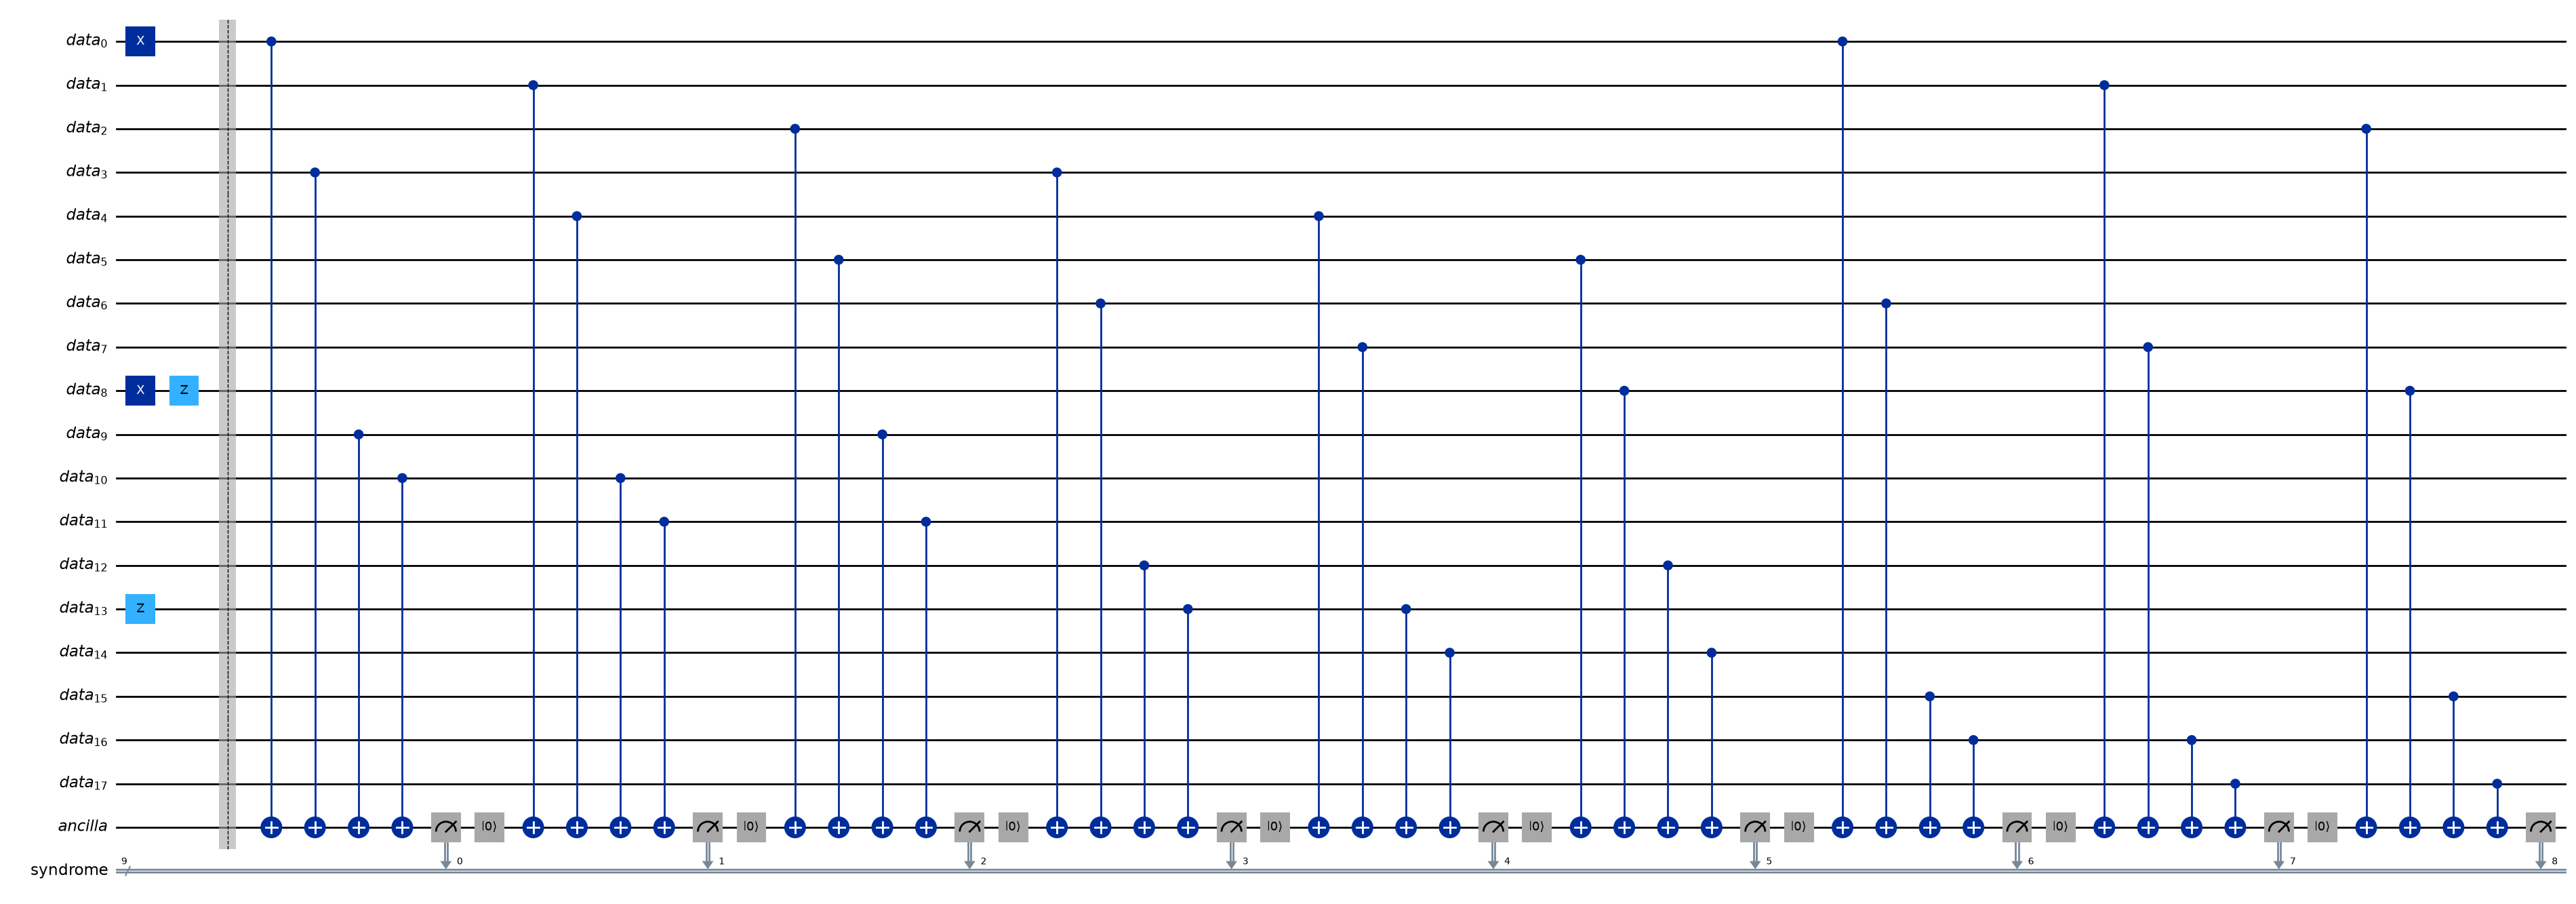

In [10]:
qiskit_result.circuits.z_checks.draw(output="mpl", fold=80)

## Conclusion

For this combined $X/Z/Y$ error, the Qiskit measurements reproduce both algebraic syndrome vectors exactly. The adapter therefore validates the translation from binary CSS check rows to ideal ancilla-based parity-measurement circuits. Noise, repeated measurement rounds, hook-error-aware scheduling, and fault tolerance remain separate later tasks.